In [5]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\YuMeow\WorkSpace\35-HuaweiCrowdSimulation\HuaweiCrowdSimulationCode


In [3]:
GCDataset.load_data(args, "./data/GC/Annotation"),

Load GC Data: 100%|██████████| 12684/12684 [01:40<00:00, 126.25it/s]
[None|base_dataset|I|Oct07 08:27:48|0:04:22.797898] Normalized x with mean=14.0942, std=1.0000
[None|base_dataset|I|Oct07 08:27:48|0:04:22.806898] Normalized y with mean=18.3459, std=1.0000
[None|base_dataset|I|Oct07 08:27:48|0:04:22.806898] Normalized map into xmin=-32.3055, xmax=34.7790, ymin=-22.1568, ymax=33.0886
[None|gc_dataset|I|Oct07 08:37:24|0:13:59.077422] Caching dataset to data\.cache\GC_2.5_8_12_1.pkl


(<src.dataset.gc_dataset.GCDataset at 0x1ff52add550>,)

In [4]:
from argparse import Namespace
from src.dataset import SDDDataset, UCYDataset, ETHDataset, GCDataset
from src.utils.logger import init_logger

init_logger('src')

args = Namespace(name='20251007_DDPM_002537_YuMeowWS', device='cuda:0', 
batch_size=256, lr=0.001, epochs=10000, T=100, hist_step=8, pred_step=12, skip_step=1, fps=2.5, dot_per_meter=5, seed=5103, save_dir='./logs/train', debug=False, model_dim=256, map_feature_dim=64, head_num=4, dropout=0.1, latent_token_num=16, beta_schedule='cosine', num_workers=0, 
cache_dataset=True, test_before_train=True, test_per_epoch=10, save_path='logs\\train\\20251007_DDPM_002537_YuMeowWS')

dataset_list = [
    *SDDDataset.load_data_batch(args, "./data/SDD/"),
    *UCYDataset.load_data_batch(args, "./data/UCY/data/"),
    *ETHDataset.load_data_batch(args, "./data/ETH/"),
    GCDataset.load_data(args, "./data/GC/Annotation"),
]


Loading ETH datasets: 100%|██████████| 2/2 [00:05<00:00,  2.88s/it, seq_hotel]
[None|gc_dataset|N|Oct07 08:38:03|0:00:35.463806] Loading cached dataset from data\.cache\GC_2.5_8_12_1.pkl


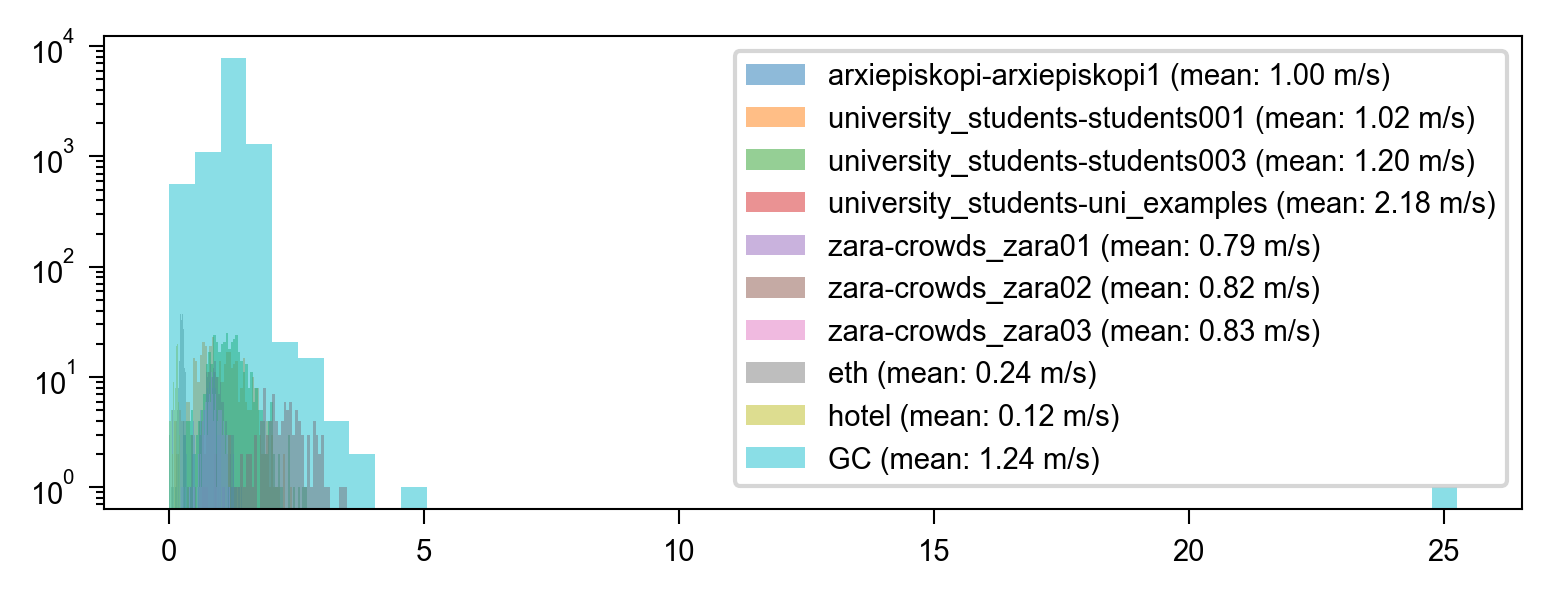

In [16]:
speed_dict = {}
for dataset in dataset_list:
    if isinstance(dataset, SDDDataset):
        continue
    df = dataset.df_data
    speed_dict[dataset.name] = []
    for id, group in df.groupby('id'):
        speed = group[['x', 'y']].diff().pow(2).sum(axis=1).pow(0.5).div(group['f'].diff() / args.fps)
        # speed_dict[dataset.name].extend(speed.dropna().tolist())
        speed_dict[dataset.name].append(speed.mean())

import numpy as np
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

fi, fig, axes = get_fig(1, 1, AW=12, AH=4, dpi=300)

for name, speeds in speed_dict.items():
    speeds = np.array(speeds)
    speeds = speeds[np.isfinite(speeds)]
    axes[0].hist(speeds, bins=50, alpha=0.5, label=f"{name} (mean: {speeds.mean():.2f} m/s)")
axes[0].semilogy()
axes[0].legend()

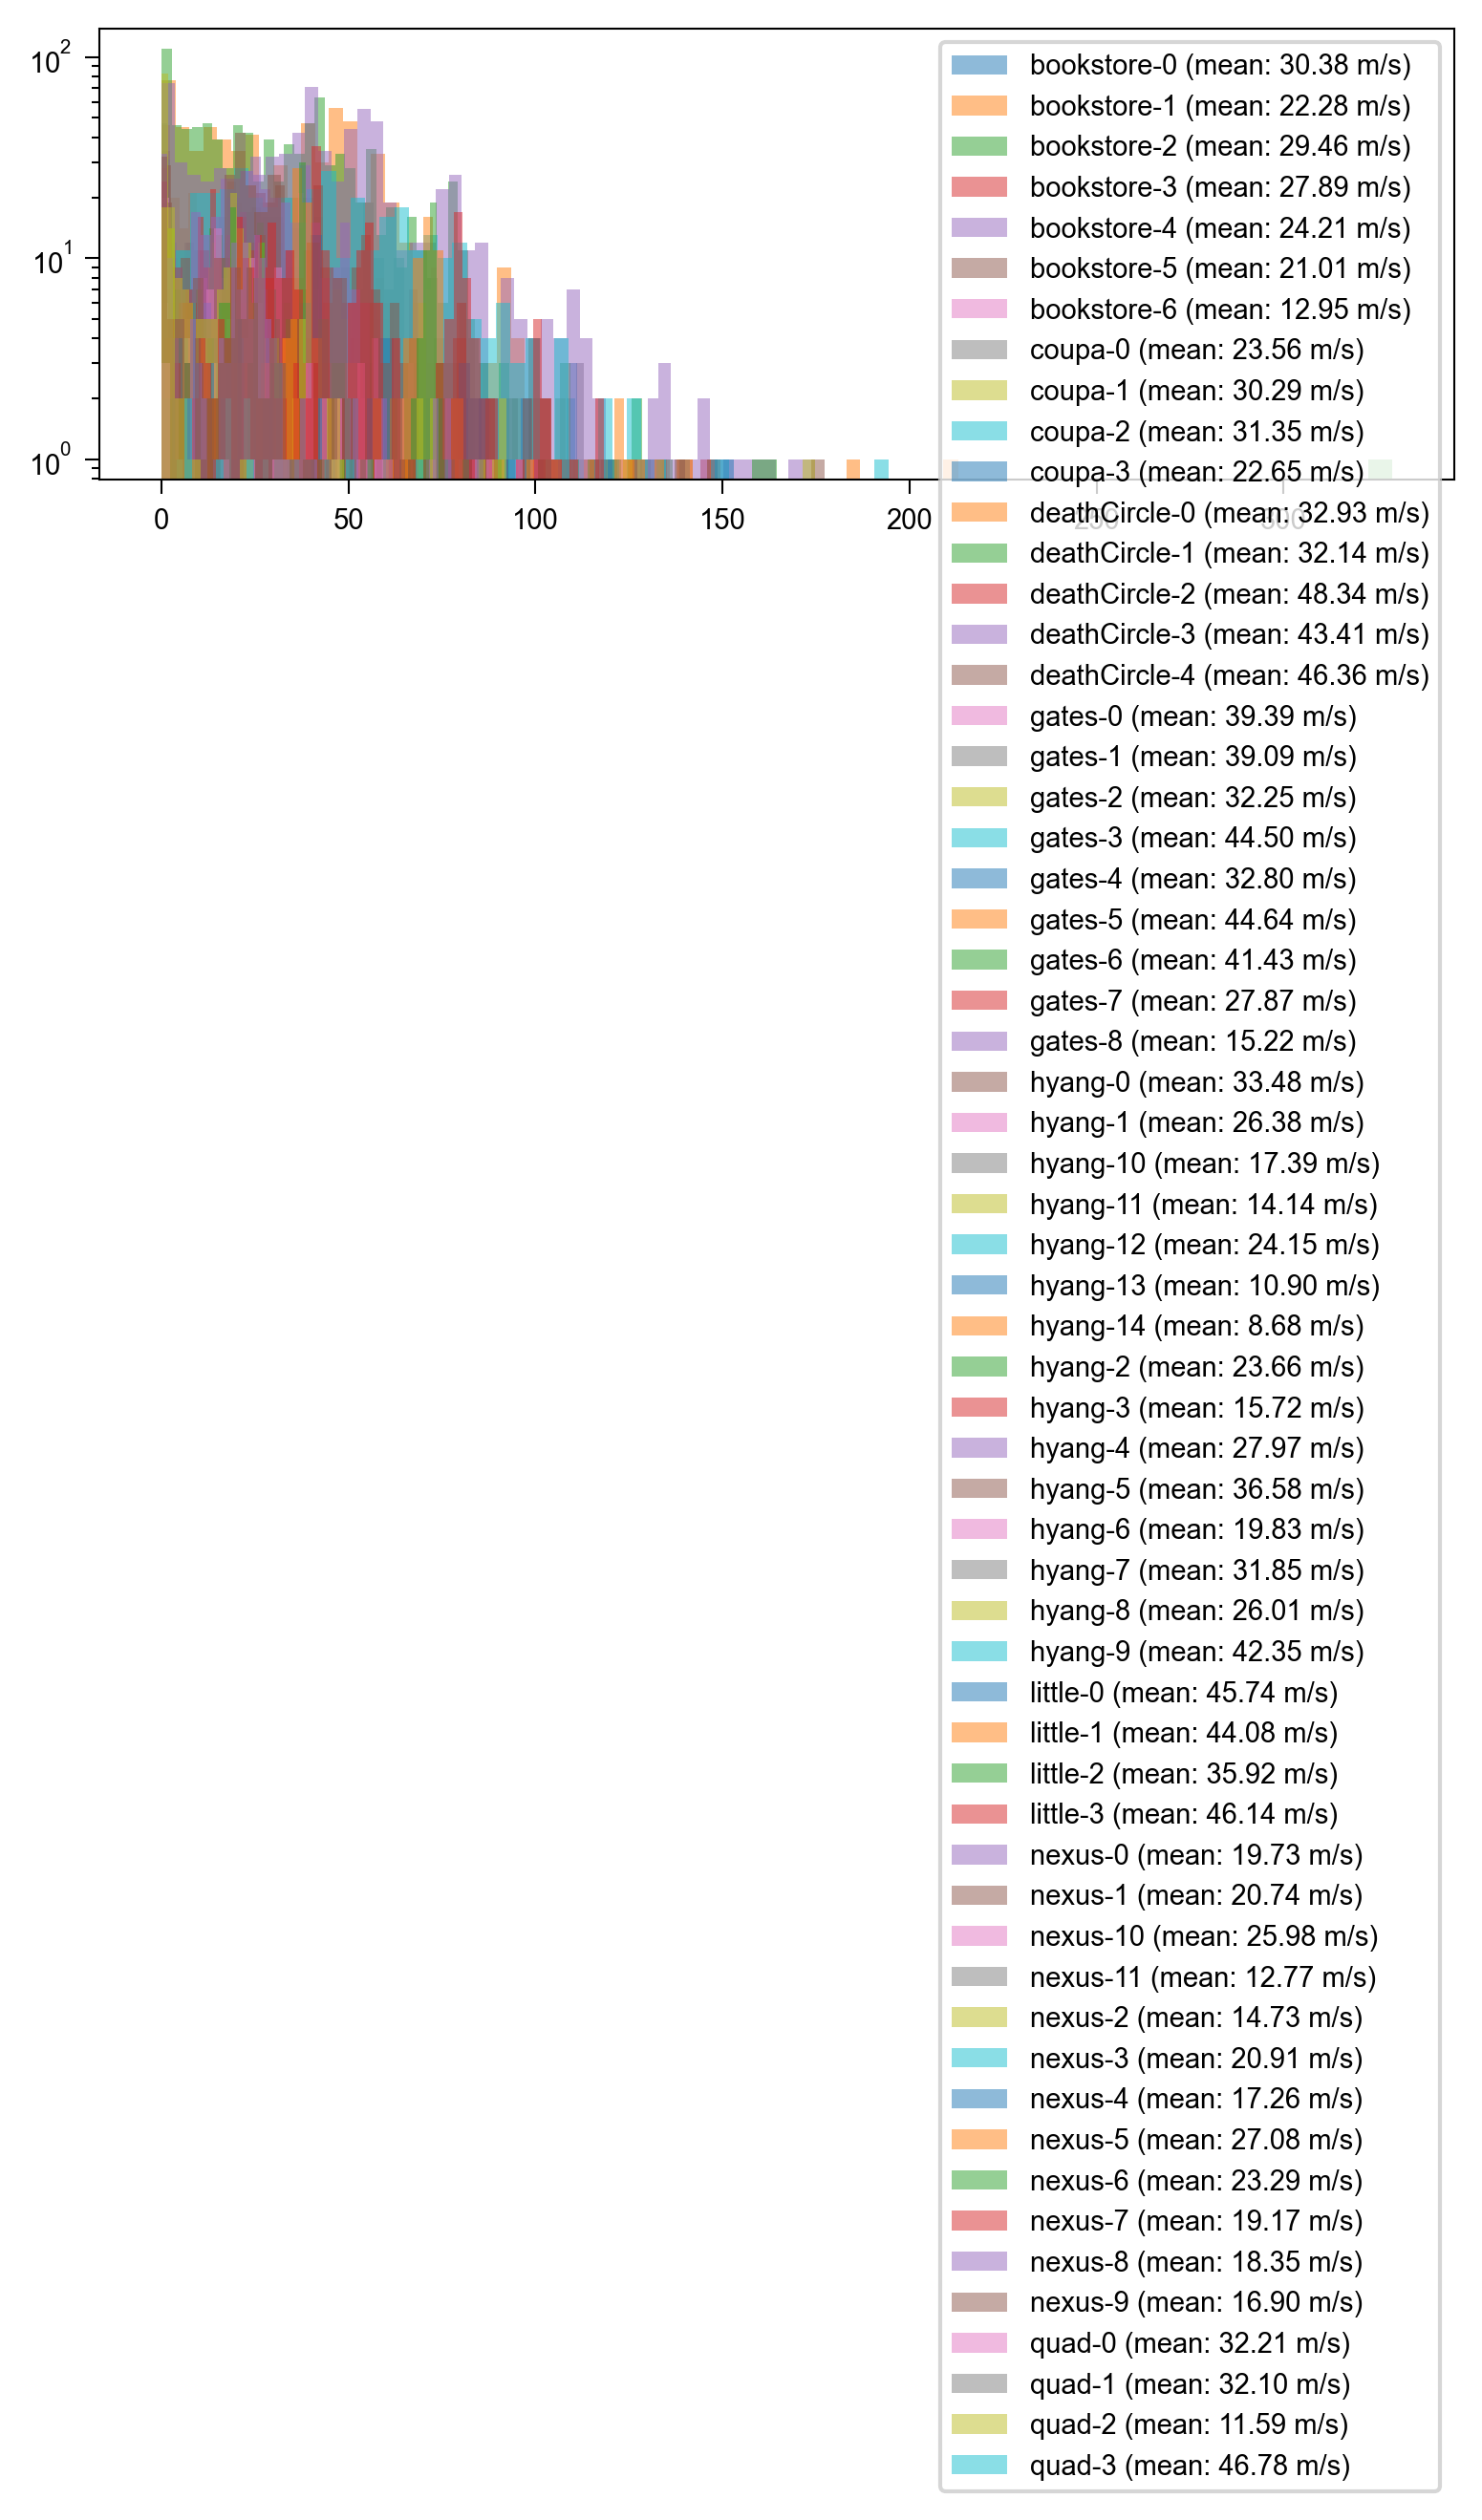

In [17]:
speed_dict = {}
for dataset in dataset_list:
    if not isinstance(dataset, SDDDataset):
        continue
    df = dataset.df_data
    speed_dict[dataset.name] = []
    for id, group in df.groupby('id'):
        speed = group[['x', 'y']].diff().pow(2).sum(axis=1).pow(0.5).div(group['f'].diff() / args.fps)
        # speed_dict[dataset.name].extend(speed.dropna().tolist())
        speed_dict[dataset.name].append(speed.mean())

import numpy as np
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

fi, fig, axes = get_fig(1, 1, AW=12, AH=4, dpi=300)

for name, speeds in speed_dict.items():
    speeds = np.array(speeds)
    speeds = speeds[np.isfinite(speeds)]
    axes[0].hist(speeds, bins=50, alpha=0.5, label=f"{name} (mean: {speeds.mean():.2f} m/s)")
axes[0].semilogy()
axes[0].legend()